In [1]:
# Packages
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy 
import pickle
import os
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib import colors

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# CA Margin lat: [18.75, 21.25, 23.75, 26.25, 28.75, 31.25, 33.75]
# CA Margin lon: [233.75, 236.25, 238.75, 241.25, 243.75, 246.25, 248.75]

# SW US lat: [31.25, 33.75, 36.25, 38.75, 41.25]
# SW US lon: [241.25, 243.75, 246.25, 248.75, 251.25, 253.75]

In [19]:
def read_in_nested_dict(root_dir):

    all_dicts = {}
    
    # Walk through the directory
    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.pkl'):
                full_path = os.path.join(subdir, file)
                dict_name = os.path.splitext(file)[0]
                with open(full_path, 'rb') as f:
                    all_dicts[dict_name] = pickle.load(f)

    return all_dicts

def to_monthly(ds):
    year = ds.time.dt.year
    month = ds.time.dt.month

    # assign new coords
    ds = ds.assign_coords(year=("time", year.data), month=("time", month.data))

    # reshape the array to (..., "month", "year")
    return ds.set_index(time=("year", "month")).unstack("time")  

def consecutive(data, stepsize = 1):
    return np.split(data, np.where(np.diff(data) != stepsize)[0] +1 )

def weighted(data):
    weights = np.cos(np.deg2rad(data.lat))
    precip_weighted = data.weighted(weights)
    data_weighted = precip_weighted.mean(("lon", "lat")).values
    return data_weighted

def nonlinear_detrend_map(data, deg, dim):

    fit = data.polyfit(dim = dim, deg = deg)
    trend_lines = xr.polyval(data[dim], fit['polyfit_coefficients'])

    detrended = data - trend_lines

    return trend_lines, detrended

def nonlinear_detrend_ts(data, order):
    length = np.shape(data)[0]
    x = np.arange(0,length,1)
    polyfit = np.polyfit(x, data,order)
    poly = np.poly1d(polyfit)
    fit = poly(x)
    detrended = data - fit

    return fit, detrended


def linear_detrend_ts(data):
    detrend = scipy.signal.detrend(data, type = 'linear')
    return detrend
    

def dsc(data,type,dim = None, deg = None):

    monthly = to_monthly(data)
    time_length = len(data)
    
    if type == 'constant':
        detrend = scipy.signal.detrend(monthly, axis = 0, type = 'constant')

    if type == 'linear':
        detrend = scipy.signal.detrend(monthly, axis = 0, type = 'linear')       

    if type == 'nonlinear':

        fit = monthly.polyfit(dim, deg)
        trend_lines = xr.polyval(monthly[dim], fit['polyfit_coefficients'])
        detrend = monthly - trend_lines
        
    deseasonalized = np.zeros(np.shape(data))
    for imonth in range(12):
        t = np.arange(imonth, time_length,12)
        deseasonalized[t] = (detrend[:,imonth])

    return deseasonalized


def get_mon(data):
    jun = data[5::12]
    jul = data[6::12]
    aug = data[7::12]
    sep = data[8::12]
    
    mon = np.array([jun,jul,aug,sep]).mean(axis = 0)

    return mon


def get_margin(ts_var):
    seasonal = ts_var.sel(lat = slice(18.75,33.75), lon = slice(233.75, 248.75))
    annual = seasonal.groupby('time.year').mean()[:]
    
    topo  = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')
    land_mask = np.where(topo.topo > 0, np.nan, 1)
    land_mask_xr = xr.DataArray(land_mask,dims=['lat', 'lon'],coords={'lat': topo.lat, 'lon':topo.lon})

    lat_ca = seasonal.lat
    lon_ca = seasonal.lon
    # print(lat_ca)
    # print(lon_ca)
    
    topo_box = land_mask_xr.sel(lat=slice(lat_ca.values[0],lat_ca.values[-1]), lon=slice(lon_ca.values[0],lon_ca.values[-1]))
    
    seasonal = seasonal*topo_box
    annual = annual*topo_box
    
    # area weighting the ca margin
    
    ann_ca_c_w = weighted(annual)
    sea_ca_c_w = weighted(seasonal)

    return ann_ca_c_w, sea_ca_c_w



def get_sw(precip_var):
    
    seasonal = precip_var.sel(lat = slice(31.25,41.25), lon = slice(241.25, 253.75))
    annual = seasonal.groupby('time.year').mean()[:]
    # print(seasonal.lat)
    # print(seasonal.lon)
    
    ann_sw_pr_c_w = weighted(annual)
    sea_sw_pr_c_w = weighted(seasonal)

    return ann_sw_pr_c_w, sea_sw_pr_c_w

def dsc_and_seasons_ts(time, type, ca_var, precip_var):

    if type == 'nonlinear':
        dsc_ca = dsc(ca_var, mpi_time, type, dim = 'year', deg= 3)
        dsc_sw = dsc(precip_var, mpi_time, type, dim = 'year', deg= 3)

    else:
        
    
        dsc_ca = dsc(ca_var, time, type )
        dsc_sw = dsc(precip_var, time, type)

    summer_ca = get_summer(dsc_ca)
    winter_ca = get_winter(dsc_ca)
    
    summer_sw = get_summer(dsc_sw)
    winter_sw = get_winter(dsc_sw)

    return summer_ca, winter_ca, summer_sw, winter_sw



def dsc_map(data,type, dim = None, deg = None):
    time_length = data.shape[0]
    monthly = to_monthly(data)

    if type == 'constant':
        
        detrend = scipy.signal.detrend(monthly, axis = 2, type = 'constant')
        detrend_shaped = np.transpose(detrend, (3,2,0,1))


    if type == 'linear':

        detrend = scipy.signal.detrend(monthly, axis = 2, type = 'linear')
        detrend_shaped = np.transpose(detrend, (3,2,0,1))
        

    if type == 'nonlinear':
                
        fit = monthly.polyfit(dim, deg)
        trend_lines = xr.polyval(monthly[dim], fit['polyfit_coefficients'])
        detrended = monthly - trend_lines
        detrend_shaped = np.transpose(np.asarray(detrended), (3,2,0,1))

    
    deseasonalized = np.zeros(np.shape(data))
    for imonth in range(12):
        t = np.arange(imonth, time_length,12)
        deseasonalized[t,:,:] = (detrend_shaped[imonth,:,:,:])

    return deseasonalized



def dsc_mon_sst_map( type, ca_var):
    years = np.array([t.year for t in ca_var.time.values])
    years = list(set(years))
    
    if type == 'nonlinear':
        sea_pr_dsc = dsc_map(ca_var,  type, dim = 'year', deg= 3)
        
    else:
        sea_pr_dsc = dsc_map(ca_var, type)

    mon_sst_dsc = get_mon(sea_pr_dsc)
    winter_sst_dsc = get_winter(sea_pr_dsc)
    mon_sst_dsc = xr.DataArray(mon_sst_dsc,dims=["time", 'lat', 'lon'],coords={"time": years, 'lat': ca_var.lat, 'lon':ca_var.lon})
    winter_sst_dsc = xr.DataArray(winter_sst_dsc,dims=["time", 'lat', 'lon'],coords={"time": years, 'lat': ca_var.lat, 'lon':ca_var.lon})

    return mon_sst_dsc, winter_sst_dsc


def dsc_mon_pr_map( type, precip_var):
    years = np.array([t.year for t in precip_var.time.values])
    years = list(set(years))
    
    if type == 'nonlinear':
        sea_pr_dsc = dsc_map(precip_var,  type, dim = 'year', deg= 3)
        
    else:
        sea_pr_dsc = dsc_map(precip_var, type)

    mon_pr_dsc = get_mon(sea_pr_dsc)
    winter_pr_dsc = get_winter(sea_pr_dsc)
    mon_pr_dsc = xr.DataArray(mon_pr_dsc,dims=["time", 'lat', 'lon'],coords={"time": years, 'lat': precip_var.lat, 'lon':precip_var.lon})
    winter_pr_dsc = xr.DataArray(winter_pr_dsc,dims=["time", 'lat', 'lon'],coords={"time": years, 'lat': precip_var.lat, 'lon':precip_var.lon})

    return mon_pr_dsc, winter_pr_dsc

In [3]:
models = {
    'CESM104': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CCSM3': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'MPIESM12': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'HadCM3L': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CNRMCM61': ['control', 'abrupt2x', 'abrupt4x']
}

In [4]:
all_data = {}

for model, exps in models.items():
    all_data[model] = {}
    for exp in exps:
        pr_path = f"/scratch/olee/research/Paleo_group/model_data/pr/pr_mon_{model}_{exp}*.nc"
        tas_path = f"/scratch/olee/research/Paleo_group/model_data/tas/tas_mon_{model}_{exp}*.nc"
        if model == 'CESM104' and exp == 'abrupt4x':
            all_data[model][exp] = {
                'pr': xr.open_mfdataset(pr_path)['pr']*86400000,
                'tas': xr.open_mfdataset(tas_path)['tas']
            }
        elif model == 'CESM104' and exp == 'abrupt8x':
            all_data[model][exp] = {
                'pr': xr.open_mfdataset(pr_path)['pr']*86400000,
                'tas': xr.open_mfdataset(tas_path)['tas']
            }
        else:
            all_data[model][exp] = {
                'pr': xr.open_mfdataset(pr_path)['pr']*86400,
                'tas': xr.open_mfdataset(tas_path)['tas']
            }

In [5]:
topo = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')

In [7]:
topo

<xarray.Dataset>
Dimensions:  (lon: 144, lat: 72)
Coordinates:
  * lon      (lon) float32 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
Data variables:
    topo     (lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Feb 16 16:22:06 2026: cdo -f nc -remapbil,/scratch/olee...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...

In [15]:
get_sw(all_data['CESM104']['control']['pr'])

<xarray.DataArray 'lat' (lat: 5)>
array([31.25, 33.75, 36.25, 38.75, 41.25], dtype=float32)
Coordinates:
  * lat      (lat) float32 31.25 33.75 36.25 38.75 41.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
<xarray.DataArray 'lon' (lon: 6)>
array([241.25, 243.75, 246.25, 248.75, 251.25, 253.75], dtype=float32)
Coordinates:
  * lon      (lon) float32 241.2 243.8 246.2 248.8 251.2 253.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X


(array([1.40681067, 1.29255979, 1.19967285, 1.70359657, 1.79077908,
        1.4717396 , 1.61773831, 1.36780025, 1.41815538, 1.54955663,
        1.50490043, 1.05801887, 1.0776033 , 1.27737523, 1.42515645,
        1.93931208, 1.18325987, 1.23802404, 1.48292807, 1.52712198,
        1.90364258, 1.23683542, 1.71941147, 1.35515456, 1.58935382,
        1.54585228, 1.30807328, 1.11930942, 1.53928759, 1.67953459,
        1.6923628 , 1.38901038, 1.34830931, 1.31314975, 1.93202188,
        0.93375646, 1.12674881, 1.66789564, 1.98312238, 1.44816666,
        1.49657007, 1.30708265, 1.48461587, 1.36112982, 1.09911721,
        1.1436837 , 1.29273157, 1.26834114, 1.93725525, 1.79366506,
        1.2681953 , 1.24566528, 0.94128136, 1.28902434, 1.56543162,
        1.2168596 , 1.4267614 , 1.35965915, 1.60551218, 2.1920922 ,
        1.75036307, 1.23838426, 1.46574181, 1.7019803 , 1.57758938,
        1.68474643, 1.36708582, 1.23413383, 1.5484057 , 1.59064729,
        1.94597096, 1.43014158, 1.6868298 , 1.09

In [17]:
get_margin(all_data['CESM104']['control']['tas'])

<xarray.DataArray 'lat' (lat: 7)>
array([18.75, 21.25, 23.75, 26.25, 28.75, 31.25, 33.75], dtype=float32)
Coordinates:
  * lat      (lat) float32 18.75 21.25 23.75 26.25 28.75 31.25 33.75
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
<xarray.DataArray 'lon' (lon: 7)>
array([233.75, 236.25, 238.75, 241.25, 243.75, 246.25, 248.75], dtype=float32)
Coordinates:
  * lon      (lon) float32 233.8 236.2 238.8 241.2 243.8 246.2 248.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X


(array([295.12258358, 295.00063573, 295.43309714, 294.79545793,
        295.43415478, 294.87907002, 294.80930374, 294.82922482,
        295.130168  , 295.35908339, 294.47555853, 294.56822222,
        294.41679974, 294.92391725, 295.26419352, 295.32286504,
        294.38627369, 294.87007372, 294.65181326, 295.24560127,
        295.41261276, 294.45124786, 294.41545373, 294.41799818,
        295.07467675, 294.75149031, 295.42179251, 295.2680927 ,
        294.95196322, 294.79854357, 295.16498913, 295.11837764,
        295.22632163, 295.15624635, 295.3184739 , 294.47444563,
        294.52315258, 294.5515073 , 294.79349801, 295.35459149,
        295.6548653 , 295.43901943, 295.15899137, 294.72688637,
        295.21618394, 295.08371108, 294.89282994, 295.58851968,
        295.58435351, 295.39622716, 295.24119373, 295.11308972,
        295.33745593, 294.91612596, 295.17921361, 295.12040967,
        294.68973134, 294.95564575, 295.00100561, 295.10517926,
        294.5604503 , 294.68929011, 294.

In [20]:
sw_dict_sea = {}

for model, exps in models.items():
    sw_dict_sea[model] = {}
    for exp in exps:
        ann, sea = get_sw(all_data[model][exp]['pr'])
        sea = xr.DataArray(sea,dims=["time"],coords={"time": all_data[model][exp]['pr'].time})
        sw_dict_sea[model][exp] = sea

In [21]:
marg_dict_sea = {}

for model, exps in models.items():
    marg_dict_sea[model] = {}
    for exp in exps:
        ann, sea = get_margin(all_data[model][exp]['tas'])
        sea = xr.DataArray(sea,dims=["time"],coords={"time": all_data[model][exp]['tas'].time})
        marg_dict_sea[model][exp] = sea

In [22]:
sw_dict_mon = {}

for model, exps in models.items():
    sw_dict_mon[model] = {}
    for exp in exps:
        years = np.array([t.year for t in all_data[model][exp]['pr'].time.values])
        years = list(set(years))
        precip = sw_dict_sea[model][exp]

        mon = get_mon(precip)
        mon = xr.DataArray(mon,dims=["time"],coords={"time": years})
        sw_dict_mon[model][exp] = mon

marg_dict_mon = {}

for model, exps in models.items():
    marg_dict_mon[model] = {}
    for exp in exps:
        years = np.array([t.year for t in all_data[model][exp]['tas'].time.values])
        years = list(set(years))
        tas = marg_dict_sea[model][exp]

        mon = get_mon(tas)
        mon = xr.DataArray(mon,dims=["time"],coords={"time": years})
        marg_dict_mon[model][exp] = mon

In [23]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/marg_dict_mon.pkl', 'wb') as f:
    pickle.dump(marg_dict_mon, f)
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/sw_dict_mon.pkl', 'wb') as f:
    pickle.dump(sw_dict_mon, f)

In [24]:
detrend_method = {
    'CESM104': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'CCSM3': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'MPIESM12': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'HadCM3L': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'CNRMCM61': ['constant', 'linear', 'nonlinear']
}

In [25]:
sw_detrend_dict_mon = {}

for model, exps in models.items():
    sw_detrend_dict_mon[model] = {}
    for exp in exps:
        years = np.array([t.year for t in all_data[model][exp]['pr'].time.values])
        years = list(set(years))[200:]
        precip = sw_dict_sea[model][exp][2400:]
        dsc_sw = dsc(precip, 'linear', dim = 'year')
        mon = get_mon(dsc_sw)
        mon = xr.DataArray(mon,dims=["time"],coords={"time": years})
        sw_detrend_dict_mon[model][exp] = mon

In [26]:
marg_detrend_dict_mon = {}

for model, exps in models.items():
    marg_detrend_dict_mon[model] = {}
    for i, exp in enumerate(exps):
        years = np.array([t.year for t in all_data[model][exp]['tas'].time.values])
        years = list(set(years))[200:]
        sst = marg_dict_sea[model][exp][2400:]
        
        method = detrend_method[model][i]
        print(method)
        if method == 'nonlinear':
            deg = 3
            dsc_sst = dsc(sst, method, dim = 'year', deg = deg)
        else:
            dsc_sst = dsc(sst, method, dim = 'year')
            
        mon = get_mon(dsc_sst)
        mon = xr.DataArray(mon,dims=["time"],coords={"time": years})
        marg_detrend_dict_mon[model][exp] = mon


constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear


In [27]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/marg_detrend_dict_mon.pkl', 'wb') as f:
    pickle.dump(marg_detrend_dict_mon, f)
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/sw_detrend_dict_mon.pkl', 'wb') as f:
    pickle.dump(sw_detrend_dict_mon, f)

In [28]:
pr_mon_map_nonanom_all = {}
tas_mon_map_nonanom_all = {}

for model, exps in models.items():
    pr_mon_map_nonanom_all[model]= {}
    tas_mon_map_nonanom_all[model]= {}
    for exp in exps:
        years = np.array([t.year for t in all_data[model][exp]['pr'].time.values])
        years = list(set(years))
        mon = get_mon(all_data[model][exp]['pr'][:,32:57, 72:117])
        lat = all_data[model][exp]['pr'][:,32:57, 72:117].lat
        lon = all_data[model][exp]['pr'][:,32:57, 72:117].lon

        mon = xr.DataArray(mon,dims=["time", "lat", "lon"],coords={"time": years, "lat": lat, "lon":lon})
        pr_mon_map_nonanom_all[model][exp] =mon

        
        mon = get_mon(all_data[model][exp]['tas'][:,32:57, 72:117])
        lat = all_data[model][exp]['tas'][:,32:57, 72:117].lat
        lon = all_data[model][exp]['tas'][:,32:57, 72:117].lon

        mon = xr.DataArray(mon,dims=["time", "lat", "lon"],coords={"time": years, "lat": lat, "lon":lon})

        tas_mon_map_nonanom_all[model][exp] = mon


In [29]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/tas_mon_map_nonanom_all.pkl', 'wb') as f:
    pickle.dump(tas_mon_map_nonanom_all, f)

with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/pr_mon_map_nonanom_all.pkl', 'wb') as f:
    pickle.dump(pr_mon_map_nonanom_all, f)


In [30]:
tas_detrend_method = {
    'CESM104': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'CCSM3': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'MPIESM12': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'HadCM3L': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'CNRMCM61': ['constant', 'linear', 'nonlinear']
}

pr_detrend_method = {
    'CESM104': ['constant', 'linear', 'linear', 'linear'],
    'CCSM3': ['constant', 'linear', 'linear', 'linear'],
    'MPIESM12': ['constant', 'linear', 'linear', 'linear'],
    'HadCM3L': ['constant', 'linear', 'linear', 'linear'],
    'CNRMCM61': ['constant', 'linear', 'linear']
}

In [31]:
sw_detrend_dict_mon_map = {}

for model, exps in models.items():
    sw_detrend_dict_mon_map[model] = {}
    for i, exp in enumerate(exps):
        method = pr_detrend_method[model][i]
        print(method)
        mon_map, winter_map = dsc_mon_pr_map(method, all_data[model][exp]['pr'][2400:,32:57, 72:117])
        sw_detrend_dict_mon_map[model][exp] = mon_map


constant
linear
linear
linear
constant
linear
linear
linear
constant
linear
linear
linear
constant
linear
linear
linear
constant
linear
linear


In [32]:
tas_detrend_dict_mon_map = {}

for model, exps in models.items():
    tas_detrend_dict_mon_map[model] = {}
    for i, exp in enumerate(exps):
        method = tas_detrend_method[model][i]
        print(method)
        mon_map, winter_map = dsc_mon_sst_map(method, all_data[model][exp]['tas'][2400:,32:57, 72:117])
        tas_detrend_dict_mon_map[model][exp] = mon_map


constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear


In [33]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/sw_detrend_dict_mon_map.pkl', 'wb') as f:
    pickle.dump(sw_detrend_dict_mon_map, f)
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/tas_detrend_dict_mon_map.pkl', 'wb') as f:
    pickle.dump(tas_detrend_dict_mon_map, f)

In [34]:
slp = {}

for model, exps in models.items():
    slp[model] = {}
    for exp in exps:
        slp_path = f"/scratch/olee/research/Paleo_group/model_data/slp/psl_mon_{model}_{exp}*.nc"
        slp[model][exp] = {
            'slp': xr.open_mfdataset(slp_path)['psl']/100

        }

In [35]:
slp_mon_map_nonanom_all = {}

for model, exps in models.items():
    slp_mon_map_nonanom_all[model]= {}

    for exp in exps:
        years = np.array([t.year for t in slp[model][exp]['slp'].time.values])
        years = list(set(years))
        mon = get_mon(slp[model][exp]['slp'][:,32:57, 72:117])
        lat =slp[model][exp]['slp'][:,32:57, 72:117].lat
        lon = slp[model][exp]['slp'][:,32:57, 72:117].lon

        mon = xr.DataArray(mon,dims=["time", "lat", "lon"],coords={"time": years, "lat": lat, "lon":lon})

        slp_mon_map_nonanom_all[model][exp] =mon

In [36]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/slp_mon_map_nonanom_all.pkl', 'wb') as f:
    pickle.dump(slp_mon_map_nonanom_all, f)

In [37]:
slp_detrend_method = {
    'CESM104': ['constant', 'linear', 'linear', 'linear'],
    'CCSM3': ['constant', 'linear', 'linear', 'linear'],
    'MPIESM12': ['constant', 'linear', 'linear', 'linear'],
    'HadCM3L': ['constant', 'linear', 'linear', 'linear'],
    'CNRMCM61': ['constant', 'linear', 'linear']
}

In [39]:
slp_detrend_dict_mon_map = {}

for model, exps in models.items():
    slp_detrend_dict_mon_map[model] = {}

    for i, exp in enumerate(exps):
        method = slp_detrend_method[model][i]
        mon_map, winter_map = dsc_mon_pr_map('linear', slp[model][exp]['slp'][2400:,32:57, 72:117])   
        slp_detrend_dict_mon_map[model][exp] = mon_map


In [40]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/slp_detrend_dict_mon_map.pkl', 'wb') as f:
    pickle.dump(slp_detrend_dict_mon_map, f)

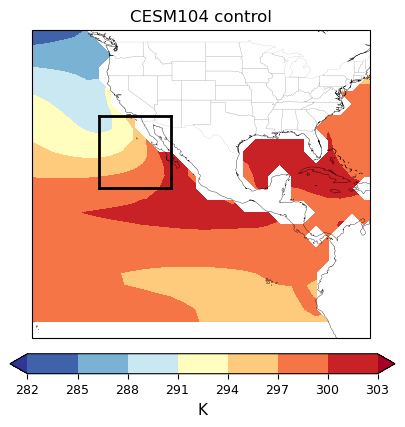

In [45]:
topo = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')
    # land_mask = np.where(topo.topo > 0, np.nan, 1)
    # land_mask = land_mask[:7,:7]
land_mask = np.where(topo.topo > 0, np.nan, 1)
land_mask_xr = xr.DataArray(land_mask,dims=['lat', 'lon'],coords={'lat': topo.lat, 'lon':topo.lon})
sst = tas_mon_map_nonanom_all['CESM104']['control'][:1000]
sst = sst[-200:].mean(axis = 0)
ca = sst.sel(lat = slice(18.75,33.75), lon = slice(233.75, 248.75))



fig, ax = plt.subplots(1,1,
                         figsize=(5,4),
                         subplot_kw={'projection': ccrs.PlateCarree()})

lon = sst.lon
lat = sst.lat

topo_box = land_mask_xr.sel(lat=slice(lat.values[0],lat.values[-1]), lon=slice(lon.values[0],lon.values[-1]))
# Plot pr control mean

c = ax.contourf(lon, lat, sst*topo_box, 
                #levels=np.linspace(10,30,30),
                cmap = 'RdYlBu_r',
                # norm = colors.TwoSlopeNorm(vcenter=14.),
                transform=ccrs.PlateCarree(),
                extend = 'both'
               )

ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=2,
            transform=ccrs.Geodetic())
    
ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=2,
        transform=ccrs.Geodetic())

ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=2,
        transform=ccrs.Geodetic())

ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=2,
        transform=ccrs.Geodetic())



ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
ax.set_extent([220,290,-10,46])
ax.set_title('CESM104 control')

cbar_ax1 = fig.add_axes([0.13, 0.02, 0.77, 0.05])  
cb=fig.colorbar(c, cax =cbar_ax1, orientation="horizontal", label="C", )
cb.ax.tick_params(labelsize=9)
cb.set_label('K', size=11)


In [46]:
def get_nino34(tas_var):
    lat = tas_var.lat
    lon = tas_var.lon

    nino_sea = tas_var.sel(lat=slice(-5,5), lon=slice(190,240))
    annual = nino_sea.groupby('time.year').mean()[:]
    # area weighting the ca margin
    
    ann_nino = weighted(annual)
    sea_nino = weighted(nino_sea)


    return ann_nino, sea_nino

In [47]:
nino_dict_sea = {}

for model, exps in models.items():
    nino_dict_sea[model] = {}
    for exp in exps:
        ann, sea = get_nino34(all_data[model][exp]['tas'])
        sea = xr.DataArray(sea,dims=["time"],coords={"time": all_data[model][exp]['tas'].time})
        nino_dict_sea[model][exp] = sea

In [48]:
nino_dict_mon = {}

for model, exps in models.items():
    nino_dict_mon[model] = {}
    for exp in exps:
        years = np.array([t.year for t in all_data[model][exp]['tas'].time.values])
        years = list(set(years))
        tas = nino_dict_sea[model][exp]

        mon = get_mon(tas)
        mon = xr.DataArray(mon,dims=["time"],coords={"time": years})
        nino_dict_mon[model][exp] = mon

In [49]:
detrend_method = {
    'CESM104': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'CCSM3': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'MPIESM12': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'HadCM3L': ['constant', 'linear', 'nonlinear', 'nonlinear'],
    'CNRMCM61': ['constant', 'linear', 'nonlinear']
}

nino_detrend_dict_mon = {}

for model, exps in models.items():
    nino_detrend_dict_mon[model] = {}
    for i, exp in enumerate(exps):
        years = np.array([t.year for t in all_data[model][exp]['tas'].time.values])
        years = list(set(years))[200:]
        sst = nino_dict_sea[model][exp][2400:]
        
        method = detrend_method[model][i]
        print(method)
        if method == 'nonlinear':
            deg = 3
            dsc_sst = dsc(sst, method, dim = 'year', deg = deg)
        else:
            dsc_sst = dsc(sst, method, dim = 'year')
            
        mon = get_mon(dsc_sst)
        mon = xr.DataArray(mon,dims=["time"],coords={"time": years})
        nino_detrend_dict_mon[model][exp] = mon

constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear
nonlinear
constant
linear
nonlinear


In [50]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/nino_dict_mon.pkl', 'wb') as f:
    pickle.dump(nino_dict_mon, f)
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/nino_detrend_dict_mon.pkl', 'wb') as f:
    pickle.dump(nino_detrend_dict_mon, f)